In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import sqlite3
import pandas as pd
# Normalisation 0-1 par colonne
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [ ]:

conn = sqlite3.connect('../data/rugby.db')
df = pd.read_sql_query("SELECT * FROM team_match_stats", conn)
matches = pd.read_sql_query("SELECT * FROM matches", conn)
teams = pd.read_sql_query("SELECT * FROM teams", conn)
conn.close()

print(df.shape)
df.head()

(472, 201)


,uid,matchEspnId,teamEspnId,opponentEspnId,linescore1stHalf,linescore2ndHalf,linescore20min,linescore60min,passes,runs,...,penaltyConcededWrongSide,won,lost,drawn,numberOfTeams,matches,startingMatches,replacementMatches,onReport,playTheBall
0,196b190c03dbd56b,597739,25912,25922,10,26,NaN,NaN,89.0,77.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,a4fbb6484a3891d3,597739,25922,25912,7,7,NaN,NaN,117.0,111.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,b36bef4da55690b2,597740,99855,143737,10,23,NaN,NaN,170.0,130.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,b43034f2cb29eb6d,597740,143737,99855,8,18,NaN,NaN,83.0,80.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ebb612e8543e007b,597741,25920,25921,7,7,NaN,NaN,93.0,81.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
fill_rate = df.notna().mean().sort_values(ascending=False) * 100
print(fill_rate[fill_rate > 0].to_string())

uid                                 100.000000
teamEspnId                          100.000000
opponentEspnId                      100.000000
linescore1stHalf                    100.000000
linescore2ndHalf                    100.000000
matchEspnId                         100.000000
freeKickConcededInRuckOrMaul         79.237288
lineoutsInfringeOwn                  79.237288
lineoutsInfringeOpp                  79.237288
totalKicksSucceeded                  79.237288
totalFreeKicksConceded               79.237288
freeKickConcededAtLineout            79.237288
freeKickConcededInGeneralPlay        79.237288
freeKickConcededAtScrum              79.237288
lineoutsToOwnPlayer                  79.237288
freeKickConceded                     79.237288
lineoutsToOppPlayer                  79.237288
lineoutThrowLostFreeKick             79.237288
lineoutWonOwnThrow                   79.237288
lineoutWonSteal                      79.237288
tryKicks                             79.237288
lineoutThrowL

In [ ]:
# Métriques de pression offensive
pression_cols = [
    'attackingEventsZoneC',  # événements dans les 22m adverses
    'attackingEventsZoneD',  # événements dans les 5m adverses
    'cleanBreaks',           # franchissements
    'defendersBeaten',       # défenseurs battus
    'metres',                # mètres gagnés
    'possession',            # possession
    'territory',             # territoire
    'carriesCrossedGainLine' # passages de la ligne d'avantage
]



df_clean = df[pression_cols].dropna()
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=pression_cols)

# Score composite
df_clean = df_clean.copy()
df_clean['OPI'] = df_scaled.mean(axis=1)

print(df_clean['OPI'].describe())
df_clean.head()

count    374.000000
mean       0.409217
std        0.128818
min        0.082163
25%        0.317875
50%        0.398167
75%        0.487821
max        0.784112
Name: OPI, dtype: float64


,attackingEventsZoneC,attackingEventsZoneD,cleanBreaks,defendersBeaten,metres,possession,territory,carriesCrossedGainLine,OPI
0,115.0,41.0,4.0,21.0,374.0,0.47,0.53,56.0,0.343383
1,107.0,84.0,4.0,24.0,382.0,0.53,0.47,61.0,0.382769
2,225.0,78.0,8.0,16.0,542.0,0.58,0.61,86.0,0.566811
3,82.0,47.0,3.0,10.0,341.0,0.42,0.39,49.0,0.220761
4,98.0,19.0,4.0,21.0,281.0,0.46,0.44,43.0,0.260066


In [9]:
# Trouver le match Toulouse vs Bordeaux-Bèglès
mask = matches['name'].str.contains('Toulousain') & matches['name'].str.contains('Bordeaux')
print(matches[mask][['espnId', 'name', 'date', 'winnerScore', 'loserScore']])

     espnId                                 name                 date  \
27   597766  Stade Toulousain vs Bordeaux Begles  2023-10-29 20:05:00   
127  597866  Bordeaux Begles vs Stade Toulousain  2024-03-24 20:05:00   
186  597925  Stade Toulousain vs Bordeaux Begles  2024-06-28 19:05:00   
213  599632  Stade Toulousain vs Bordeaux Begles  2024-09-29 19:05:00   

     winnerScore  loserScore  
27            29          22  
127           31          28  
186           59           3  
213           16          12  


In [ ]:

conn = sqlite3.connect('../data/rugby.db')
df = pd.read_sql_query("SELECT * FROM team_match_stats", conn)
matches = pd.read_sql_query("SELECT * FROM matches", conn)
teams = pd.read_sql_query("SELECT * FROM teams", conn)
conn.close()

print("team_match_stats:", df.shape)
print("matches:", matches.shape)
print("teams:", teams.shape)
print("\nÉquipes disponibles:")
print(teams[['espnId', 'name']])

team_match_stats: (472, 201)
matches: (236, 13)
teams: (14, 5)

Équipes disponibles:
    espnId                  name
0    25912               Bayonne
1    25916     Castres Olympique
2    25917     Clermont Auvergne
3    25918   Montpellier Herault
4    25920             Perpignan
5    25921  Stade Francais Paris
6    25922      Stade Toulousain
7    25986                Toulon
8    99855             Racing 92
9   119318           La Rochelle
10  143736                  Lyon
11  143737       Bordeaux Begles
12  190153               Oyonnax
13  270567                   Pau


In [ ]:

pression_cols = [
    'attackingEventsZoneC',
    'attackingEventsZoneD', 
    'cleanBreaks',
    'defendersBeaten',
    'metres',
    'possession',
    'territory',
    'carriesCrossedGainLine'
]

df_clean = df[['teamEspnId', 'matchEspnId'] + pression_cols].dropna()
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_clean[pression_cols]), columns=pression_cols)
df_clean = df_clean.copy()
df_clean['OPI'] = df_scaled.mean(axis=1)

print(f"{len(df_clean)} lignes exploitables")

374 lignes exploitables


                   name       OPI  won
0               Bayonne  0.343383    1
1      Stade Toulousain  0.382769    0
2             Racing 92  0.566811    1
3       Bordeaux Begles  0.220761    0
4             Perpignan  0.260066    0
5  Stade Francais Paris  0.325068    1
6               Oyonnax  0.172618    1
7     Clermont Auvergne  0.351343    0
8     Castres Olympique  0.395152    1
9                   Pau  0.450195    0


In [5]:
df_opi.groupby('name')['matchEspnId'].count().sort_values()

name
Bayonne                 26
Castres Olympique       26
Clermont Auvergne       26
Lyon                    26
Montpellier Herault     26
Oyonnax                 26
Pau                     26
Perpignan               26
Racing 92               27
Stade Francais Paris    27
Toulon                  27
La Rochelle             28
Stade Toulousain        28
Bordeaux Begles         29
Name: matchEspnId, dtype: int64

Matplotlib is building the font cache; this may take a moment.
/var/folders/h6/8xq2tnfj7cz5nc2m6hvsn6b80000gp/T/ipykernel_5156/2535170217.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=opi_by_team, x='OPI', y='name', palette='RdYlGn')


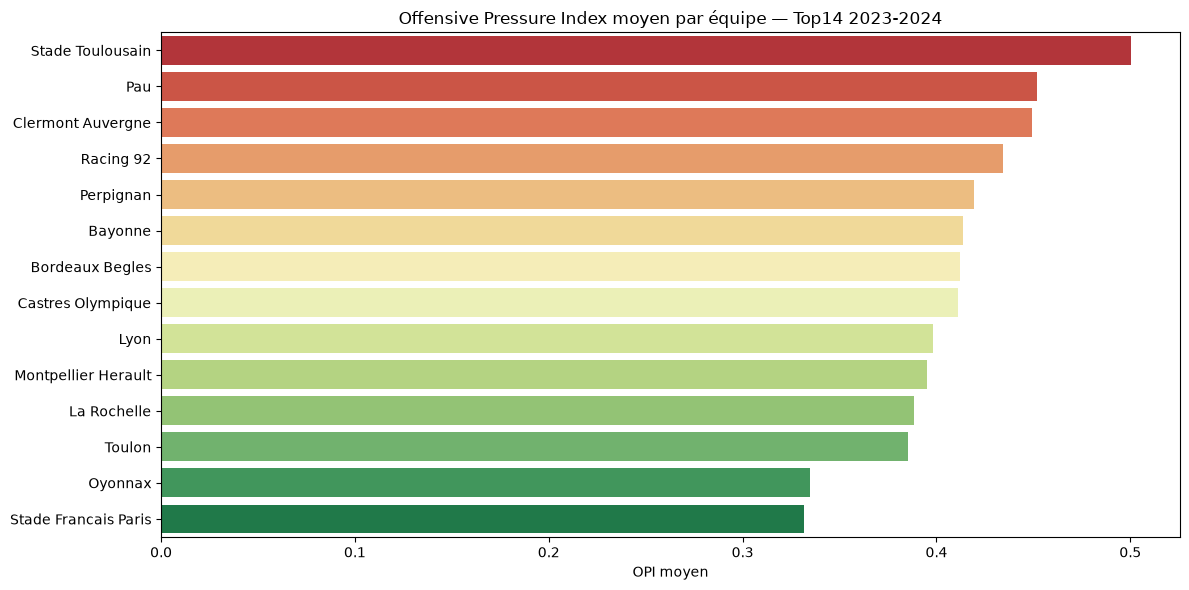

In [ ]:

opi_by_team = df_opi.groupby('name')['OPI'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=opi_by_team, x='OPI', y='name', palette='RdYlGn')
plt.title('Offensive Pressure Index moyen par équipe — Top14 2023-2024')
plt.xlabel('OPI moyen')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:


# Connexion à la base
conn = sqlite3.connect("../data/rugby.db")

# Ta requête SQL
df = pd.read_sql("""
    SELECT matchEspnId, teamEspnId, cleanBreaks, metres, possession
    FROM team_match_stats
    LIMIT 10
""", conn)

# Afficher le tableau
df

,matchEspnId,teamEspnId,cleanBreaks,metres,possession
0,597739,25912,4.0,374.0,0.47
1,597739,25922,4.0,382.0,0.53
2,597740,99855,8.0,542.0,0.58
3,597740,143737,3.0,341.0,0.42
4,597741,25920,4.0,281.0,0.46
5,597741,25921,3.0,286.0,0.54
6,597742,190153,1.0,186.0,0.45
7,597742,25917,4.0,285.0,0.55
8,597743,25916,8.0,543.0,0.43
9,597743,270567,2.0,358.0,0.57


In [14]:
conn = sqlite3.connect("../data/rugby.db")

df_matches = pd.read_sql("""
    SELECT 
        m.espnId,
        m.winnerEspnId,
        m.loserEspnId,
        m.winnerScore,
        m.loserScore,
        tw.name AS winner_name,
        tl.name AS loser_name
    FROM matches m
    JOIN teams tw ON tw.espnId = m.winnerEspnId
    JOIN teams tl ON tl.espnId = m.loserEspnId
    WHERE m.winnerEspnId IS NOT NULL
    AND m.date <= '2024-06-09'
    AND m.date >= '2023-08-18'
""", conn)

# Calcul du classement
wins = df_matches.groupby('winner_name').agg(
    victoires=('espnId', 'count'),
    points_marques=('winnerScore', 'sum'),
    points_encaisses=('loserScore', 'sum')
).reset_index().rename(columns={'winner_name': 'equipe'})

losses = df_matches.groupby('loser_name').agg(
    defaites=('espnId', 'count'),
    points_marques=('loserScore', 'sum'),
    points_encaisses=('winnerScore', 'sum')
).reset_index().rename(columns={'loser_name': 'equipe'})

classement = wins.merge(losses, on='equipe', how='outer').fillna(0)
classement['matchs'] = classement['victoires'] + classement['defaites']
classement['points_marques'] = classement['points_marques_x'] + classement['points_marques_y']
classement['points_encaisses'] = classement['points_encaisses_x'] + classement['points_encaisses_y']
classement['diff'] = classement['points_marques'] - classement['points_encaisses']
classement['pts_classement'] = classement['victoires'] * 4

classement = classement[['equipe', 'matchs', 'victoires', 'defaites', 'points_marques', 'points_encaisses', 'diff', 'pts_classement']]
classement = classement.sort_values('pts_classement', ascending=False).reset_index(drop=True)
classement.index += 1

classement

,equipe,matchs,victoires,defaites,points_marques,points_encaisses,diff,pts_classement
1,Stade Francais Paris,26,17,9,539,511,28,68
2,Stade Toulousain,26,16,10,765,592,173,64
3,Bordeaux Begles,26,15,11,677,558,119,60
4,Toulon,26,15,11,704,519,185,60
5,La Rochelle,26,14,12,595,496,99,56
6,Castres Olympique,26,13,13,643,642,1,52
7,Clermont Auvergne,26,13,13,621,671,-50,52
8,Pau,26,13,13,630,609,21,52
9,Perpignan,26,13,13,634,701,-67,52
10,Racing 92,26,13,13,622,546,76,52


In [16]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../data/rugby.db")

# Récupération des matchs + essais depuis team_match_stats
df = pd.read_sql("""
    SELECT 
        m.espnId,
        m.homeTeamEspnId,
        m.awayTeamEspnId,
        m.winnerEspnId,
        m.loserEspnId,
        m.winnerScore,
        m.loserScore,
        th.name AS home_name,
        ta.name AS away_name,
        tms_h.tries AS home_tries,
        tms_a.tries AS away_tries
    FROM matches m
    JOIN teams th ON th.espnId = m.homeTeamEspnId
    JOIN teams ta ON ta.espnId = m.awayTeamEspnId
    JOIN team_match_stats tms_h ON tms_h.matchEspnId = m.espnId AND tms_h.teamEspnId = m.homeTeamEspnId
    JOIN team_match_stats tms_a ON tms_a.matchEspnId = m.espnId AND tms_a.teamEspnId = m.awayTeamEspnId
    WHERE m.date < '2024-06-09'
    AND m.date >= '2023-08-18'
""", conn)

# On construit une ligne par équipe et par match
def build_team_rows(row):
    rows = []
    if row['winnerEspnId'] == row['homeTeamEspnId']:
        home_score, away_score = row['winnerScore'], row['loserScore']
    elif row['winnerEspnId'] == row['awayTeamEspnId']:
        home_score, away_score = row['loserScore'], row['winnerScore']
    else:  # match nul
        home_score = away_score = row['winnerScore'] if pd.notna(row['winnerScore']) else 0
    
    for equipe, tries, tries_adv, score_pour, score_contre in [
        (row['home_name'], row['home_tries'], row['away_tries'], home_score, away_score),
        (row['away_name'], row['away_tries'], row['home_tries'], away_score, home_score)
    ]:
        if score_pour > score_contre:
            resultat, pts = 'V', 4
        elif score_pour < score_contre:
            resultat, pts = 'D', 0
        else:
            resultat, pts = 'N', 2
        
        # Bonus offensif : uniquement en V ou D, +3 essais d'écart minimum
        bonus_off = 1 if (resultat != 'N' and (tries - tries_adv) >= 3) else 0
        # Bonus défensif : défaite par 5 pts ou moins
        bonus_def = 1 if (resultat == 'D' and (score_contre - score_pour) <= 5) else 0
        
        rows.append({
            'equipe': equipe,
            'resultat': resultat,
            'pts_match': pts + bonus_off + bonus_def,
            'victoires': 1 if resultat == 'V' else 0,
            'nuls': 1 if resultat == 'N' else 0,
            'defaites': 1 if resultat == 'D' else 0,
            'points_marques': score_pour,
            'points_encaisses': score_contre,
            'bonus_off': bonus_off,
            'bonus_def': bonus_def,
        })
    return rows

# On applique
all_rows = []
for _, row in df.iterrows():
    all_rows.extend(build_team_rows(row))

df_teams = pd.DataFrame(all_rows)

# Classement final
classement = df_teams.groupby('equipe').agg(
    matchs=('resultat', 'count'),
    victoires=('victoires', 'sum'),
    nuls=('nuls', 'sum'),
    defaites=('defaites', 'sum'),
    points_marques=('points_marques', 'sum'),
    points_encaisses=('points_encaisses', 'sum'),
    bonus_off=('bonus_off', 'sum'),
    bonus_def=('bonus_def', 'sum'),
    pts_classement=('pts_match', 'sum'),
).reset_index()

classement['diff'] = classement['points_marques'] - classement['points_encaisses']
classement = classement.sort_values(['pts_classement', 'diff'], ascending=[False, False]).reset_index(drop=True)
classement.index += 1

classement

,equipe,matchs,victoires,nuls,defaites,points_marques,points_encaisses,bonus_off,bonus_def,pts_classement,diff
1,Stade Toulousain,26,16,1,9,765,592,7,3,76,173
2,Stade Francais Paris,26,17,1,8,539,511,4,1,75,28
3,Toulon,26,15,0,11,704,519,5,4,69,185
4,Bordeaux Begles,26,15,0,11,677,558,5,4,69,119
5,La Rochelle,26,13,1,12,595,496,5,7,66,99
6,Racing 92,26,13,0,13,622,546,5,5,62,76
7,Castres Olympique,26,13,0,13,643,642,4,6,62,1
8,Clermont Auvergne,26,12,2,12,621,671,6,3,61,-50
9,Pau,26,13,0,13,630,609,3,5,60,21
10,Perpignan,26,13,0,13,634,701,5,1,58,-67


In [26]:
top_points = pd.read_sql("""
    SELECT 
        p.firstName || ' ' || p.lastName AS joueur,
        t.name AS equipe,
        p.positionName AS poste,
        SUM(pms.points) AS points_total,
        SUM(pms.tries) AS essais,
        SUM(pms.conversionGoals) AS transformations,
        SUM(pms.penaltyGoals) AS penalites,
        SUM(pms.dropGoalsConverted) AS drops,
        COUNT(pms.matchEspnId) AS matchs_joues
    FROM player_match_stats pms
    JOIN player_team pt ON pt.uid = pms.playerTeamUid
    JOIN players p ON p.espnId = pt.playerEspnId
    JOIN teams t ON t.espnId = pt.teamEspnId
    JOIN matches m ON m.espnId = pms.matchEspnId
    WHERE m.date < '2024-06-09'
    AND m.date >= '2023-08-18'
    AND pms.minutesPlayedTotal > 0
    GROUP BY p.espnId, t.name
    ORDER BY points_total DESC
    LIMIT 20
""", conn)

top_points

,joueur,equipe,poste,points_total,essais,transformations,penalites,drops,matchs_joues
0,Joe Simmonds,Pau,fly-half,246.0,1.0,44.0,51.0,0.0,22
1,Camille Lopez,Bayonne,fly-half,227.0,0.0,49.0,40.0,3.0,26
2,Louis Carbonel,Montpellier Herault,fly-half,194.0,1.0,39.0,36.0,1.0,24
3,Melvyn Jaminet,Toulon,fullback,194.0,3.0,28.0,41.0,0.0,12
4,Pierre Popelin,Castres Olympique,fullback,175.0,3.0,29.0,34.0,0.0,21
5,Tommaso Allan,Perpignan,fly-half,173.0,5.0,32.0,28.0,0.0,17
6,Paddy Jackson,Lyon,fly-half,168.0,2.0,31.0,30.0,2.0,24
7,Domingo Miotti,Oyonnax,fly-half,164.0,0.0,25.0,37.0,1.0,20
8,Tristan Tedder,Racing 92,fullback,145.0,4.0,22.0,27.0,0.0,22
9,Joris Segonds,Stade Francais Paris,fly-half,142.0,1.0,19.0,30.0,3.0,22


In [25]:
top_essais = pd.read_sql("""
    SELECT 
        p.firstName || ' ' || p.lastName AS joueur,
        t.name AS equipe,
        p.positionName AS poste,
        SUM(pms.tries) AS essais,
        COUNT(pms.matchEspnId) AS matchs_joues,
        ROUND(CAST(SUM(pms.tries) AS FLOAT) / COUNT(pms.matchEspnId), 2) AS essais_par_match
    FROM player_match_stats pms
    JOIN player_team pt ON pt.uid = pms.playerTeamUid
    JOIN players p ON p.espnId = pt.playerEspnId
    JOIN teams t ON t.espnId = pt.teamEspnId
    JOIN matches m ON m.espnId = pms.matchEspnId
    WHERE m.date < '2024-06-09'
    AND m.date >= '2023-08-18'
    AND pms.minutesPlayedTotal > 0
    GROUP BY p.espnId, t.name
    HAVING SUM(pms.tries) > 0
    ORDER BY essais DESC
    LIMIT 20
""", conn)

top_essais

,joueur,equipe,poste,essais,matchs_joues,essais_par_match
0,Baptiste Couilloud,Lyon,scrum-half,17.0,22,0.77
1,Damian Penaud,Bordeaux Begles,wing,14.0,13,1.08
2,Tavite Veredamu,Perpignan,wing,12.0,22,0.55
3,Bautista Delguy,Clermont Auvergne,wing,11.0,18,0.61
4,Alivereti Raka,Clermont Auvergne,wing,10.0,18,0.56
5,Jeremy Ward,Stade Francais Paris,centre,9.0,21,0.43
6,Jack Maddocks,Pau,fullback,9.0,18,0.50
7,Samuel Ezeala,Pau,wing,9.0,17,0.53
8,Matthis Lebel,Stade Toulousain,wing,9.0,15,0.60
9,Leicester Fainga'anuku,Toulon,wing,9.0,13,0.69


  resultat   statut_ht  nb_matchs
0        D      Menait          4
1        D  Menait pas          6
2        V      Menait         14
3        V  Menait pas          2


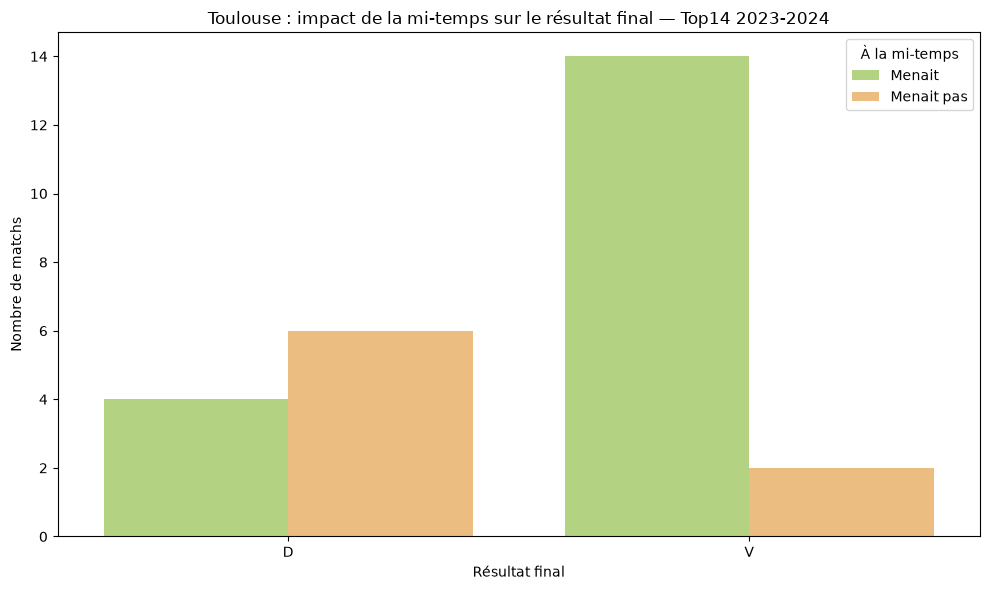

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

df_tls = pd.read_sql("""
    SELECT 
        m.espnId,
        m.date,
        m.winnerEspnId,
        tms_tls.linescore1stHalf AS tls_ht,
        tms_adv.linescore1stHalf AS adv_ht,
        CASE WHEN m.winnerEspnId = tls.espnId THEN 'V' ELSE 'D' END AS resultat
    FROM matches m
    JOIN teams tls ON tls.name = 'Stade Toulousain'
    JOIN team_match_stats tms_tls 
        ON tms_tls.matchEspnId = m.espnId AND tms_tls.teamEspnId = tls.espnId
    JOIN team_match_stats tms_adv 
        ON tms_adv.matchEspnId = m.espnId AND tms_adv.teamEspnId = tms_tls.opponentEspnId
    WHERE (m.homeTeamEspnId = tls.espnId OR m.awayTeamEspnId = tls.espnId)
    AND m.date < '2024-06-09'
    AND m.date >= '2023-08-18'
""", conn)

# Statut à la mi-temps
df_tls['statut_ht'] = df_tls.apply(
    lambda r: 'Menait' if r['tls_ht'] > r['adv_ht'] 
    else ('Menait' if r['tls_ht'] == r['adv_ht'] else 'Menait pas'),
    axis=1
)

# Comptage
counts = df_tls.groupby(['resultat', 'statut_ht']).size().reset_index(name='nb_matchs')
print(counts)

# Graphe
plt.figure(figsize=(10, 6))
sns.barplot(data=counts, x='resultat', y='nb_matchs', hue='statut_ht', palette='RdYlGn_r')
plt.title('Toulouse : impact de la mi-temps sur le résultat final — Top14 2023-2024')
plt.xlabel('Résultat final')
plt.ylabel('Nombre de matchs')
plt.legend(title='À la mi-temps')
plt.tight_layout()
plt.show()

In [28]:
import requests
import time

# 1. Récupérer les IDs des matchs de Toulouse (phase régulière uniquement)
matchs_tls = pd.read_sql("""
    SELECT m.espnId, m.date, m.name, m.homeTeamEspnId, m.awayTeamEspnId,
           m.winnerEspnId, m.winnerScore, m.loserScore
    FROM matches m
    JOIN teams tls ON tls.name = 'Stade Toulousain'
    WHERE (m.homeTeamEspnId = tls.espnId OR m.awayTeamEspnId = tls.espnId)
    AND m.date < '2024-06-09'
    AND m.date >= '2023-08-18'
    ORDER BY m.date
""", conn)

TOULOUSE_ID = 25912  # ESPN ID de Toulouse (vu dans les curl)
LEAGUE_ID = 270559
BASE_URL = f"http://sports.core.api.espn.com/v2/sports/rugby/leagues/{LEAGUE_ID}"

# 2. Fonction pour récupérer les plays d'un match
def get_plays(match_id):
    url = f"{BASE_URL}/events/{match_id}/competitions/{match_id}/plays?limit=500"
    r = requests.get(url, timeout=30)
    if r.status_code != 200:
        return []
    return r.json().get('items', [])

# 3. Récupérer tous les plays des matchs de Toulouse
print(f"Récupération des plays pour {len(matchs_tls)} matchs...")
all_plays = []
for i, row in matchs_tls.iterrows():
    plays = get_plays(row['espnId'])
    for play in plays:
        # On garde uniquement les actions de score (essai, transfo, pénalité, drop)
        if play['type']['text'] in ['try', 'conversion', 'penalty goal', 'drop goal']:
            team_ref = play.get('team', {}).get('$ref', '')
            # Extraire l'ID de l'équipe depuis l'URL
            team_id = int(team_ref.split('/teams/')[1].split('?')[0]) if '/teams/' in team_ref else None
            all_plays.append({
                'match_id': row['espnId'],
                'match_name': row['name'],
                'match_date': row['date'],
                'action': play['type']['text'],
                'minute': play['clock']['displayValue'],
                'seconds': play['clock']['value'],
                'period': play['period']['number'],
                'team_id': team_id,
                'home_score': play['homeScore'],
                'away_score': play['awayScore'],
                'home_team_id': row['homeTeamEspnId'],
                'away_team_id': row['awayTeamEspnId'],
            })
    time.sleep(0.3)  # petite pause pour ne pas spammer ESPN
    if (i+1) % 5 == 0:
        print(f"  {i+1}/{len(matchs_tls)} matchs traités...")

df_plays = pd.DataFrame(all_plays)
print(f"\n✅ {len(df_plays)} actions de score récupérées sur {len(matchs_tls)} matchs")
df_plays.head(10)

Récupération des plays pour 26 matchs...
  5/26 matchs traités...
  10/26 matchs traités...
  15/26 matchs traités...
  20/26 matchs traités...
  25/26 matchs traités...

✅ 373 actions de score récupérées sur 26 matchs


,match_id,match_name,match_date,action,minute,seconds,period,team_id,home_score,away_score,home_team_id,away_team_id
0,597739,Bayonne vs Stade Toulousain,2023-08-18 19:05:00,try,23',1346.0,1,25922,0,5,25912,25922
1,597739,Bayonne vs Stade Toulousain,2023-08-18 19:05:00,conversion,24',1403.0,1,25922,0,7,25912,25922
2,597739,Bayonne vs Stade Toulousain,2023-08-18 19:05:00,try,26',1526.0,1,25912,5,7,25912,25922
3,597739,Bayonne vs Stade Toulousain,2023-08-18 19:05:00,conversion,27',1587.0,1,25912,7,7,25912,25922
4,597739,Bayonne vs Stade Toulousain,2023-08-18 19:05:00,drop goal,41',2445.0,1,25912,10,7,25912,25922
5,597739,Bayonne vs Stade Toulousain,2023-08-18 19:05:00,penalty goal,46',2712.0,2,25912,13,7,25912,25922
6,597739,Bayonne vs Stade Toulousain,2023-08-18 19:05:00,drop goal,51',3057.0,2,25912,16,7,25912,25922
7,597739,Bayonne vs Stade Toulousain,2023-08-18 19:05:00,try,54',3207.0,2,25912,21,7,25912,25922
8,597739,Bayonne vs Stade Toulousain,2023-08-18 19:05:00,conversion,55',3277.0,2,25912,23,7,25912,25922
9,597739,Bayonne vs Stade Toulousain,2023-08-18 19:05:00,penalty goal,67',4016.0,2,25912,26,7,25912,25922


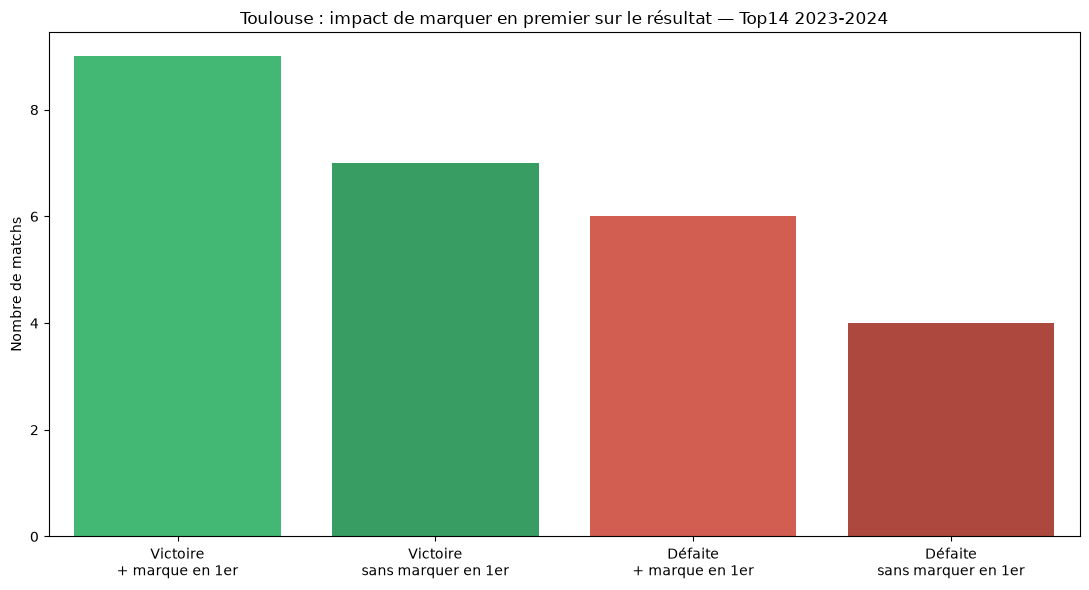


📊 Statistiques :
Toulouse marque en premier : 15/26 matchs
  → Victoires quand marque en premier : 9/15
  → Victoires quand ne marque pas en premier : 7/11


In [33]:
TOULOUSE_ID = 25922  # ✅ le bon ID de Toulouse

# Pour chaque match, trouver la première action de score
premiers_scores = df_plays.sort_values('seconds').groupby('match_id').first().reset_index()
premiers_scores['tls_marque_premier'] = premiers_scores['team_id'] == TOULOUSE_ID

resultats = matchs_tls[['espnId', 'winnerEspnId']].copy()
resultats['tls_gagne'] = resultats['winnerEspnId'] == TOULOUSE_ID
resultats = resultats.rename(columns={'espnId': 'match_id'})

analyse = premiers_scores[['match_id', 'tls_marque_premier']].merge(
    resultats[['match_id', 'tls_gagne']], on='match_id'
)

def categoriser(row):
    if row['tls_gagne'] and row['tls_marque_premier']:
        return 'Victoire\n+ marque en 1er'
    elif row['tls_gagne'] and not row['tls_marque_premier']:
        return 'Victoire\nsans marquer en 1er'
    elif not row['tls_gagne'] and row['tls_marque_premier']:
        return 'Défaite\n+ marque en 1er'
    else:
        return 'Défaite\nsans marquer en 1er'

analyse['categorie'] = analyse.apply(categoriser, axis=1)
counts = analyse['categorie'].value_counts().reset_index()
counts.columns = ['categorie', 'nb_matchs']

plt.figure(figsize=(11, 6))
sns.barplot(data=counts, x='categorie', y='nb_matchs', hue='categorie', 
            palette=['#2ecc71', '#27ae60', '#e74c3c', '#c0392b'], legend=False)
plt.title('Toulouse : impact de marquer en premier sur le résultat — Top14 2023-2024')
plt.ylabel('Nombre de matchs')
plt.xlabel('')
plt.tight_layout()
plt.show()

total_marque_premier = analyse['tls_marque_premier'].sum()
victoires_si_marque_premier = analyse[analyse['tls_marque_premier']]['tls_gagne'].sum()
victoires_si_ne_marque_pas = analyse[~analyse['tls_marque_premier']]['tls_gagne'].sum()
print(f"\n📊 Statistiques :")
print(f"Toulouse marque en premier : {total_marque_premier}/{len(analyse)} matchs")
print(f"  → Victoires quand marque en premier : {victoires_si_marque_premier}/{total_marque_premier}")
print(f"  → Victoires quand ne marque pas en premier : {victoires_si_ne_marque_pas}/{len(analyse)-total_marque_premier}")

In [34]:
import requests
import time

# Récupérer tous les matchs de la phase régulière
tous_matchs = pd.read_sql("""
    SELECT espnId, date, name, homeTeamEspnId, awayTeamEspnId, winnerEspnId
    FROM matches
    WHERE date < '2024-06-09' AND date >= '2023-08-18'
    ORDER BY date
""", conn)

print(f"À scraper : {len(tous_matchs)} matchs")

LEAGUE_ID = 270559
BASE_URL = f"http://sports.core.api.espn.com/v2/sports/rugby/leagues/{LEAGUE_ID}"

def get_plays(match_id):
    url = f"{BASE_URL}/events/{match_id}/competitions/{match_id}/plays?limit=500"
    try:
        r = requests.get(url, timeout=30)
        if r.status_code != 200:
            return []
        return r.json().get('items', [])
    except:
        return []

all_plays = []
for i, row in tous_matchs.iterrows():
    plays = get_plays(row['espnId'])
    for play in plays:
        if play['type']['text'] in ['try', 'conversion', 'penalty goal', 'drop goal']:
            team_ref = play.get('team', {}).get('$ref', '')
            team_id = int(team_ref.split('/teams/')[1].split('?')[0]) if '/teams/' in team_ref else None
            all_plays.append({
                'match_id': row['espnId'],
                'action': play['type']['text'],
                'minute_display': play['clock']['displayValue'],
                'seconds': play['clock']['value'],
                'period': play['period']['number'],
                'team_id': team_id,
                'home_score': play['homeScore'],
                'away_score': play['awayScore'],
            })
    time.sleep(0.2)
    if (i+1) % 20 == 0:
        print(f"  {i+1}/{len(tous_matchs)}")

df_plays_all = pd.DataFrame(all_plays)
print(f"\n✅ {len(df_plays_all)} actions récupérées")

# Sauvegarder dans la base pour ne plus jamais re-scraper
df_plays_all.to_sql('plays', conn, if_exists='replace', index=False)
print("✅ Table 'plays' créée dans rugby.db")

df_plays_all.head()

À scraper : 182 matchs
  20/182
  40/182
  60/182
  80/182
  100/182
  120/182
  140/182
  160/182
  180/182

✅ 2445 actions récupérées
✅ Table 'plays' créée dans rugby.db


,match_id,action,minute_display,seconds,period,team_id,home_score,away_score
0,597739,try,23',1346.0,1,25922,0,5
1,597739,conversion,24',1403.0,1,25922,0,7
2,597739,try,26',1526.0,1,25912,5,7
3,597739,conversion,27',1587.0,1,25912,7,7
4,597739,drop goal,41',2445.0,1,25912,10,7


In [35]:
# Récupérer tous les matchs + noms des équipes
matchs_avec_equipes = pd.read_sql("""
    SELECT m.espnId AS match_id, 
           m.homeTeamEspnId, m.awayTeamEspnId, m.winnerEspnId,
           th.name AS home_name, ta.name AS away_name
    FROM matches m
    JOIN teams th ON th.espnId = m.homeTeamEspnId
    JOIN teams ta ON ta.espnId = m.awayTeamEspnId
    WHERE m.date < '2024-06-09' AND m.date >= '2023-08-18'
""", conn)

# Premier scoreur de chaque match
premiers = df_plays_all.sort_values('seconds').groupby('match_id').first().reset_index()[['match_id', 'team_id']]
premiers = premiers.rename(columns={'team_id': 'first_scorer_id'})

# Merger
data = matchs_avec_equipes.merge(premiers, on='match_id')

# Construire une ligne par équipe et par match
rows = []
for _, m in data.iterrows():
    for team_id, team_name in [(m['homeTeamEspnId'], m['home_name']),
                                (m['awayTeamEspnId'], m['away_name'])]:
        rows.append({
            'equipe': team_name,
            'marque_premier': team_id == m['first_scorer_id'],
            'gagne': team_id == m['winnerEspnId'],
        })

df_analyse = pd.DataFrame(rows)

# Stats par équipe
stats = df_analyse.groupby('equipe').apply(lambda g: pd.Series({
    'nb_matchs': len(g),
    'nb_marque_premier': g['marque_premier'].sum(),
    'V_si_marque_premier': g[g['marque_premier']]['gagne'].sum(),
    'V_si_ne_marque_pas': g[~g['marque_premier']]['gagne'].sum(),
})).reset_index()

stats['pct_V_si_marque_premier'] = (stats['V_si_marque_premier'] / stats['nb_marque_premier'] * 100).round(1)
stats['pct_V_si_ne_marque_pas'] = (stats['V_si_ne_marque_pas'] / (stats['nb_matchs'] - stats['nb_marque_premier']) * 100).round(1)
stats['impact_marquer_1er'] = (stats['pct_V_si_marque_premier'] - stats['pct_V_si_ne_marque_pas']).round(1)

stats = stats.sort_values('impact_marquer_1er', ascending=False).reset_index(drop=True)
stats

,equipe,nb_matchs,nb_marque_premier,V_si_marque_premier,V_si_ne_marque_pas,pct_V_si_marque_premier,pct_V_si_ne_marque_pas,impact_marquer_1er
0,Bordeaux Begles,26,17,13,2,76.5,22.2,54.3
1,Toulon,26,15,11,4,73.3,36.4,36.9
2,Castres Olympique,26,12,8,5,66.7,35.7,31.0
3,Racing 92,26,12,8,5,66.7,35.7,31.0
4,Pau,26,19,11,2,57.9,28.6,29.3
5,Montpellier Herault,26,15,7,2,46.7,18.2,28.5
6,La Rochelle,26,10,7,7,70.0,43.8,26.2
7,Oyonnax,26,11,5,3,45.5,20.0,25.5
8,Clermont Auvergne,26,15,9,4,60.0,36.4,23.6
9,Bayonne,26,7,4,7,57.1,36.8,20.3


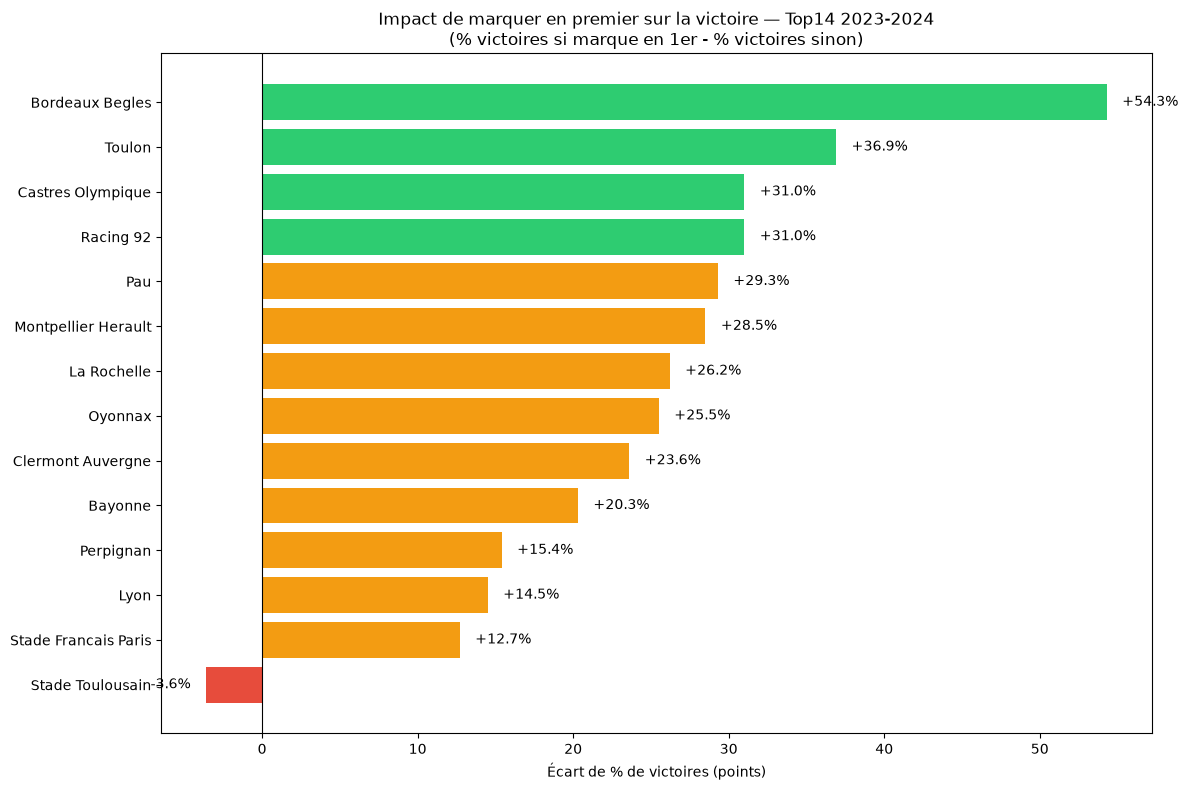

In [36]:
plt.figure(figsize=(12, 8))
colors = ['#e74c3c' if v < 0 else '#2ecc71' if v > 30 else '#f39c12' for v in stats['impact_marquer_1er']]
bars = plt.barh(stats['equipe'][::-1], stats['impact_marquer_1er'][::-1], color=colors[::-1])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title("Impact de marquer en premier sur la victoire — Top14 2023-2024\n(% victoires si marque en 1er - % victoires sinon)", fontsize=12)
plt.xlabel('Écart de % de victoires (points)')
for i, (bar, val) in enumerate(zip(bars, stats['impact_marquer_1er'][::-1])):
    plt.text(val + (1 if val >= 0 else -1), i, f'{val:+.1f}%', 
             va='center', ha='left' if val >= 0 else 'right', fontsize=10)
plt.tight_layout()
plt.show()